# Amazon Sales Data Analysis

## Objective
Analyze Amazon sales data to identify sales trends, customer behavior, product performance, and provide business insights.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


## Upload the Dataset

Upload the Amazon Sales dataset (`Amazon Sale Report.csv`) from your local system to Google Colab for analysis.

In [35]:
from google.colab import files

uploaded = files.upload()


Saving Amazon Sale Report.csv to Amazon Sale Report (1).csv


## Load the Dataset

Load the uploaded Amazon Sales dataset into a Pandas DataFrame.

In [36]:
df = pd.read_csv("Amazon Sale Report.csv")

In [37]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


## Dataset Overview

Let's understand the structure of the dataset by checking its size, columns, and data types.

In [38]:
df.shape

(128976, 21)

In [39]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

## Missing Values

Check for missing values in each column before cleaning the dataset.

In [41]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


## Data Cleaning

Handle missing values in the dataset before analysis.

In [42]:
# Fill missing values

df["Amount"] = df["Amount"].fillna(0)
df["currency"] = df["currency"].fillna("Unknown")

df["ship-city"] = df["ship-city"].fillna("Unknown")
df["ship-state"] = df["ship-state"].fillna("Unknown")
df["ship-postal-code"] = df["ship-postal-code"].fillna(0)
df["ship-country"] = df["ship-country"].fillna("Unknown")

df["fulfilled-by"] = df["fulfilled-by"].fillna("Not Specified")
df["New"] = df["New"].fillna("Not Available")
df["PendingS"] = df["PendingS"].fillna("Not Available")

In [43]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


## Duplicate Records

Check whether the dataset contains duplicate records.

In [44]:
df.duplicated().sum()

np.int64(168)

## Remove Duplicate Records

Remove duplicate rows to improve data quality and ensure accurate analysis.

In [45]:
df = df.drop_duplicates()

In [46]:
df.duplicated().sum()

np.int64(0)

## Date Formatting

Convert the `Date` column to datetime format for time-based analysis.

In [47]:
df["Date"] = pd.to_datetime(df["Date"])

/tmp/ipykernel_2922/936118274.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [48]:
df["Date"].dtype

dtype('<M8[ns]')

## Dataset Summary

Generate descriptive statistics to understand the distribution of numerical data.

In [49]:
df.describe()

,index,Date,Qty,Amount,ship-postal-code
count,128808.000000,128808,128808.000000,128808.000000,128808.000000
mean,64564.582906,2022-05-12 12:17:48.529904896,0.904416,609.409248,463838.207464
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,0.000000
25%,32368.750000,2022-04-20 00:00:00,1.000000,413.000000,382421.000000
50%,64570.500000,2022-05-10 00:00:00,1.000000,583.425000,500033.000000
75%,96772.250000,2022-06-04 00:00:00,1.000000,771.000000,600024.000000
max,128974.000000,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000
std,37193.614079,NaN,0.313373,313.381045,191597.932943


## Key Performance Indicators (KPIs)

Calculate the basic business metrics from the dataset.

In [50]:
total_revenue = df["Amount"].sum()
total_orders = df["Order ID"].nunique()
total_quantity = df["Qty"].sum()
average_order_value = df["Amount"].mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", average_order_value)

Total Revenue: 78496786.39000002
Total Orders: 120229
Total Quantity Sold: 116496
Average Order Value: 609.4092477951681


## Monthly Sales Trend

Analyze how sales changed over different months to identify overall sales patterns.

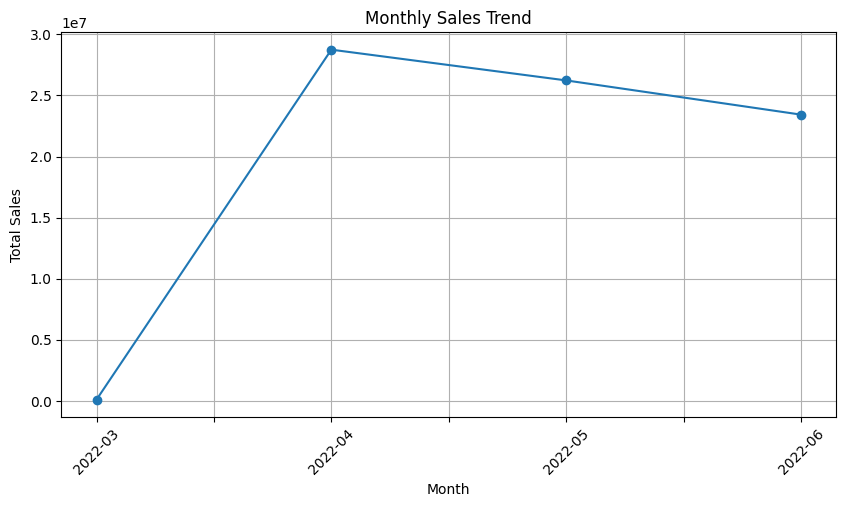

In [51]:
# Create Month-Year column
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Amount"].sum()

# Plot
plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Insight

- Sales data spans from **March 2022 to June 2022**.
- The monthly sales trend helps identify periods of higher and lower revenue, enabling better business planning and inventory management.

## Order Status Distribution

Analyze the distribution of order statuses to evaluate order fulfillment performance.

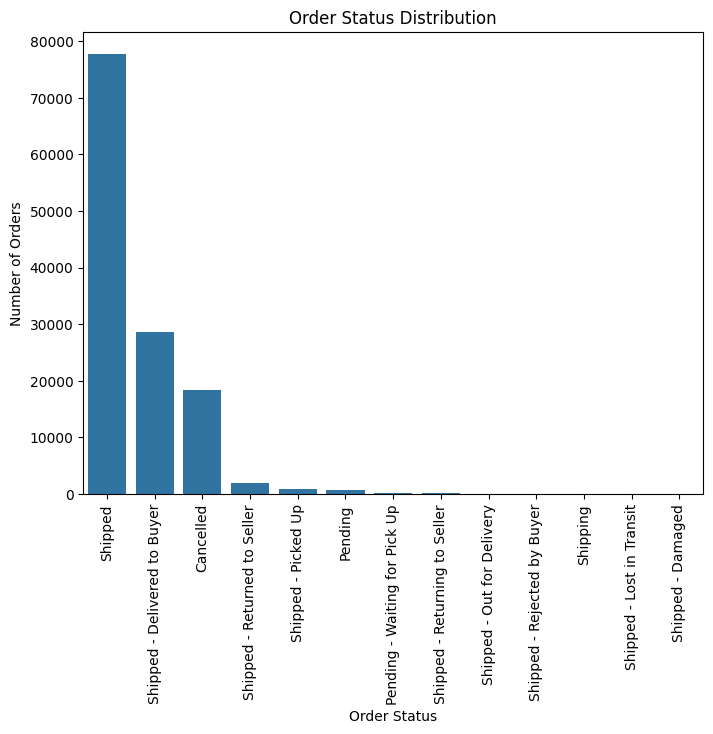

In [52]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Status", order=df["Status"].value_counts().index)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)

plt.show()

### Insight

- Most orders were successfully processed or shipped, indicating efficient order fulfillment.
- A smaller number of orders were cancelled or returned, highlighting opportunities to further improve customer satisfaction and delivery efficiency.

## Top 10 Product Categories

Identify the most frequently ordered product categories.

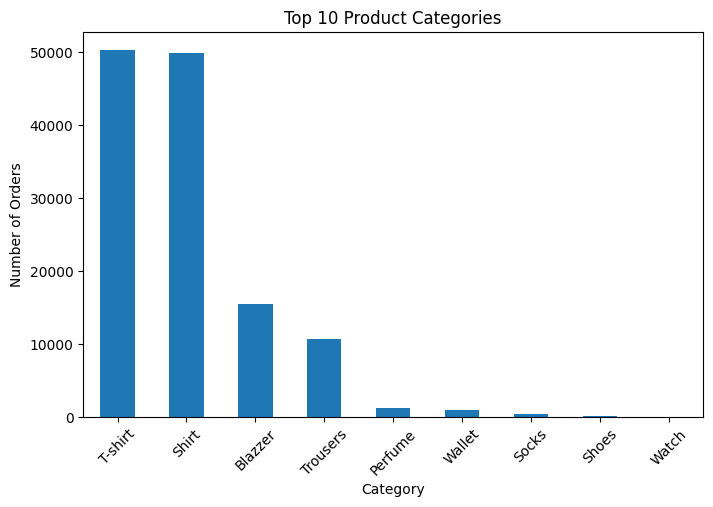

In [53]:
plt.figure(figsize=(8,5))

df["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Insight

- The chart highlights the most frequently ordered product categories.
- High-demand categories contribute significantly to overall sales and should be prioritized for inventory planning.

## Sales by Product Category

Analyze the total revenue generated by each product category.

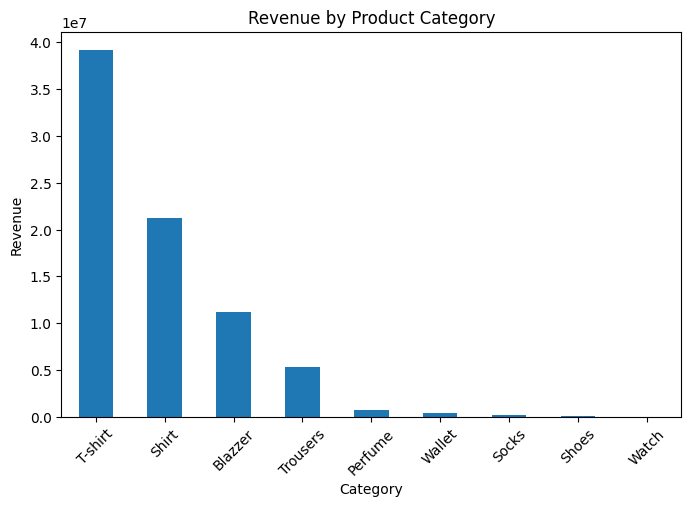

In [54]:
category_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Insight

- Revenue is concentrated in a few product categories, indicating their strong contribution to overall sales.
- Focusing on high-revenue categories can help maximize profitability and improve inventory planning.

## Top 10 States by Revenue

Analyze which states generate the highest sales revenue.

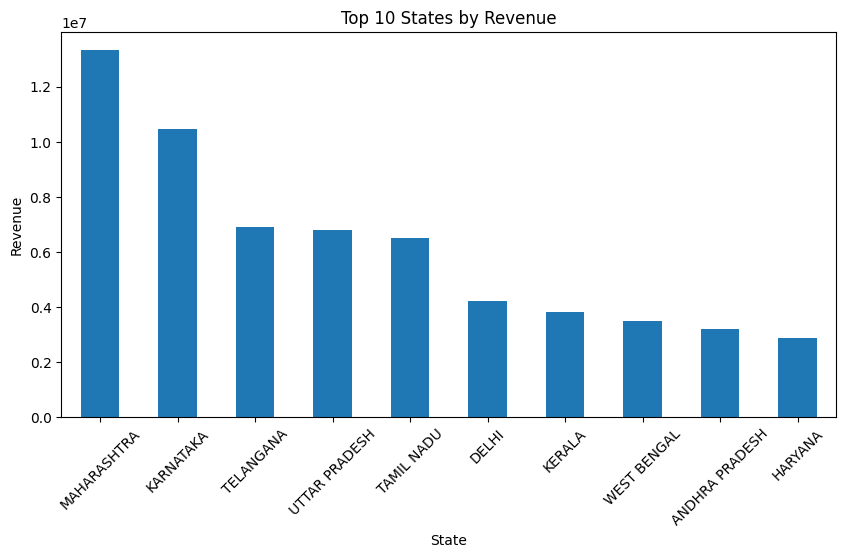

In [55]:
state_sales = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
state_sales.plot(kind="bar")

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Insight

- The top-performing states contribute a significant share of total revenue.
- These regions should be prioritized for inventory planning and marketing campaigns.

## Product Size Distribution

Analyze the distribution of product sizes ordered by customers.

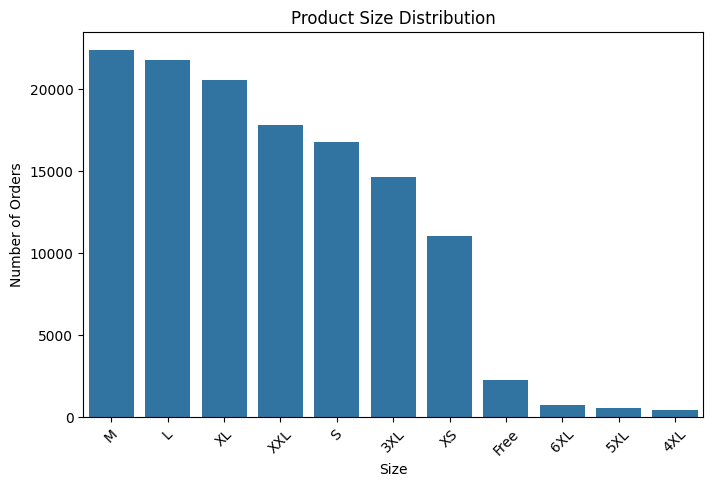

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Size",
    order=df["Size"].value_counts().index
)

plt.title("Product Size Distribution")
plt.xlabel("Size")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Insight

- Medium-sized products receive the highest number of orders.
- Understanding size preferences helps optimize inventory management and reduce stock shortages.

## Fulfilment Method Analysis

Analyze the distribution of orders based on the fulfilment method.

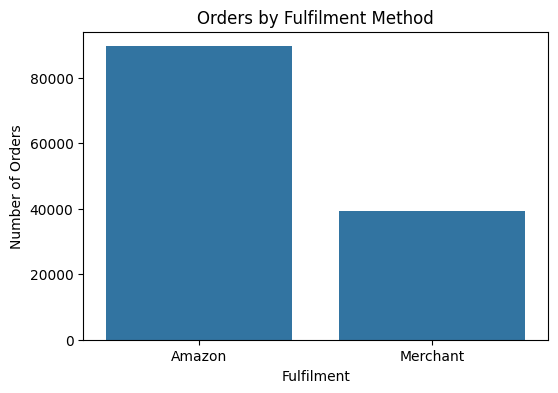

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Fulfilment",
    order=df["Fulfilment"].value_counts().index
)

plt.title("Orders by Fulfilment Method")
plt.xlabel("Fulfilment")
plt.ylabel("Number of Orders")

plt.show()

### Insight

- The chart compares the number of orders fulfilled by different fulfilment methods.
- The dominant fulfilment method can be prioritized to improve delivery efficiency and customer satisfaction.

## Sales Channel Analysis

Analyze the distribution of orders across different sales channels.

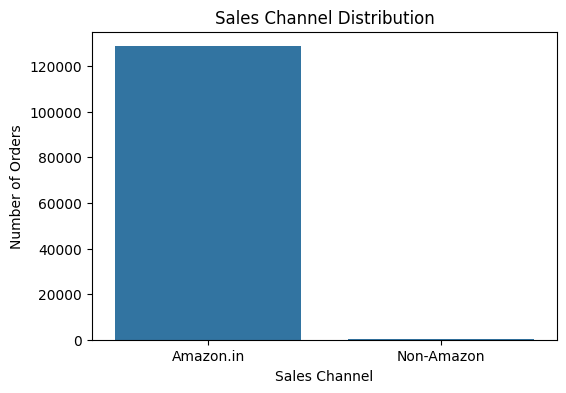

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sales Channel",
    order=df["Sales Channel"].value_counts().index
)

plt.title("Sales Channel Distribution")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Orders")

plt.show()

### Insight

- This chart shows how orders are distributed across different sales channels.
- Understanding channel performance helps businesses optimize their sales strategy.

## Top 10 Cities by Orders

Analyze which cities have the highest number of customer orders.

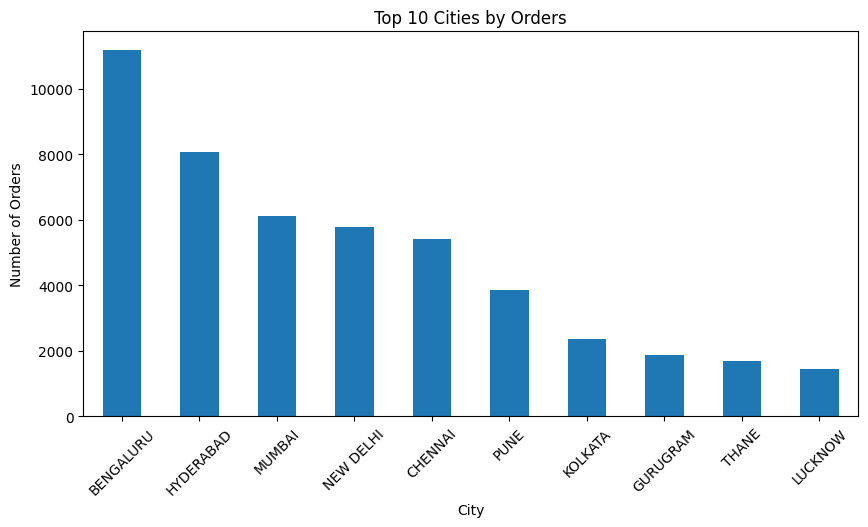

In [59]:
top_cities = df["ship-city"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Insight

- The top cities account for a large share of total orders.
- These locations can be targeted for marketing campaigns and warehouse optimization.

## Courier Status Distribution

Analyze the status of courier deliveries to understand shipping performance.

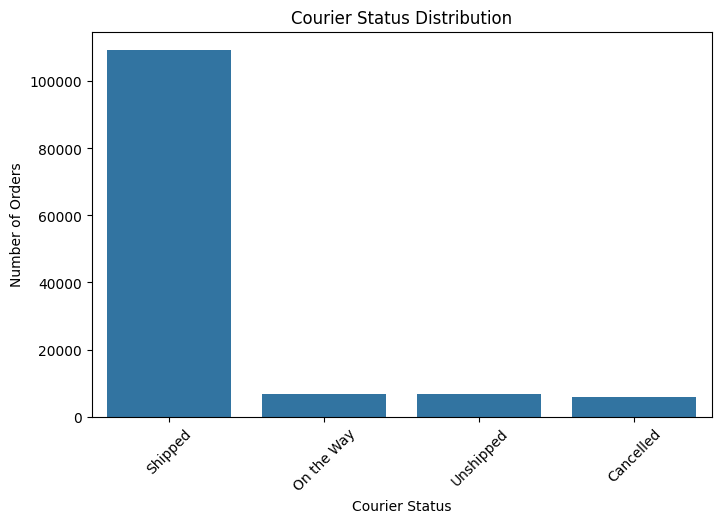

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Courier Status",
    order=df["Courier Status"].value_counts().index
)

plt.title("Courier Status Distribution")
plt.xlabel("Courier Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Insight

- Most orders were successfully shipped, indicating effective logistics operations.
- Monitoring courier status helps identify delivery delays and improve customer satisfaction.

## Correlation Heatmap

This heatmap shows the correlation between numerical variables in the dataset. It helps identify whether there is a relationship between quantity sold and sales amount.

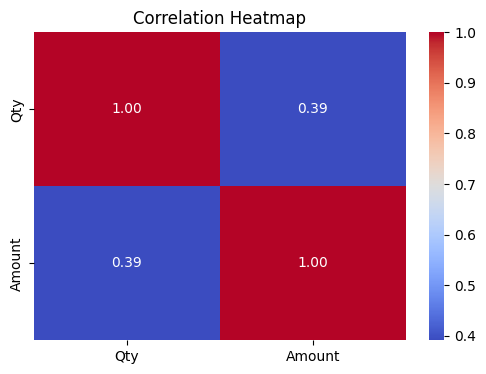

In [61]:
plt.figure(figsize=(6,4))

correlation = df[['Qty', 'Amount']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Insight

- The heatmap shows the relationship between **Quantity** and **Amount**.
- A positive correlation indicates that higher quantities sold generally contribute to higher sales revenue.

## Top 10 States by Number of Orders

Analyze which states have the highest number of customer orders.

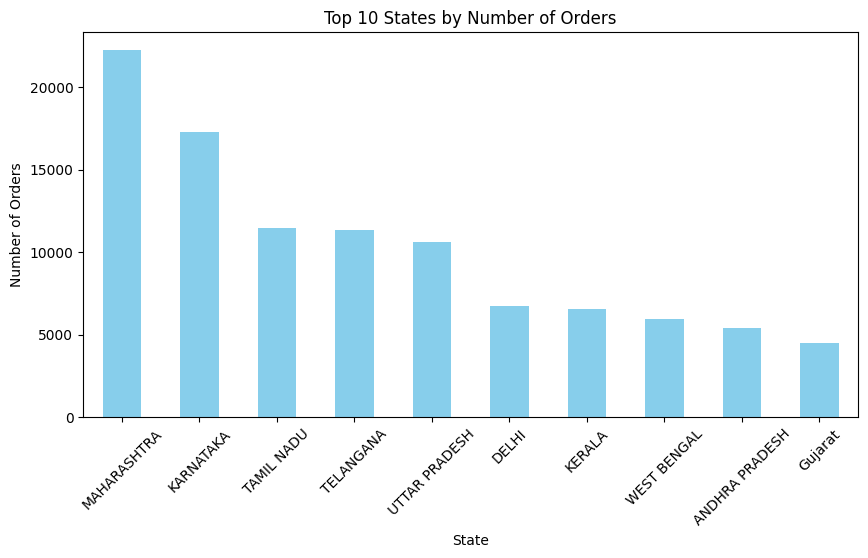

In [62]:
top_states = df["ship-state"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar", color="skyblue")

plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Insight

- The top 10 states account for the highest number of customer orders.
- These states represent key markets and should be prioritized for inventory planning and targeted marketing.

## Top 10 Cities by Revenue

Analyze the cities that generated the highest sales revenue.

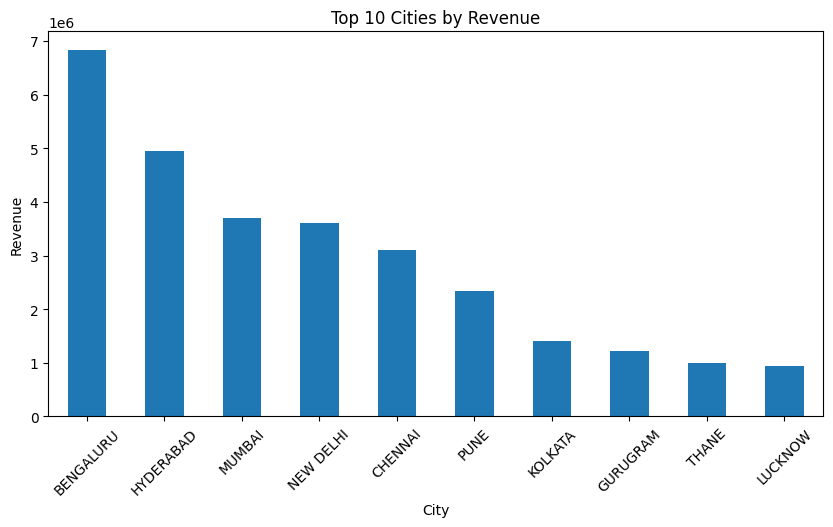

In [63]:
city_revenue = (
    df.groupby("ship-city")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
city_revenue.plot(kind="bar")

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Insight

- A few cities contribute a significant portion of the total revenue.
- These cities can be targeted for premium marketing campaigns and faster delivery services.

## Monthly Order Count

Analyze the number of orders placed each month to identify customer purchasing trends.

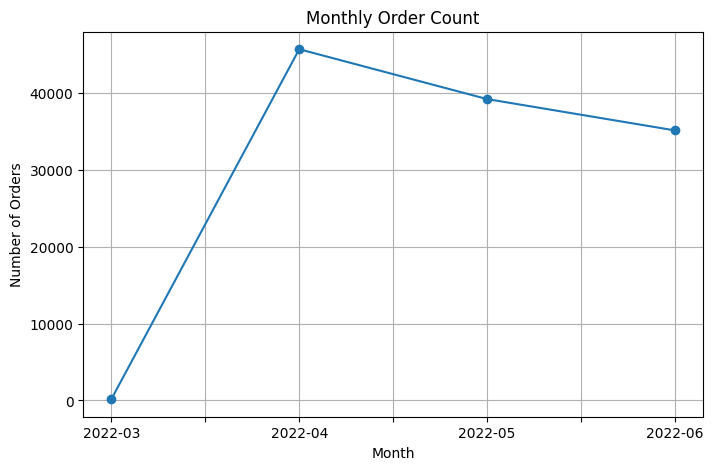

In [64]:
monthly_orders = df.groupby("Month")["Order ID"].nunique()

plt.figure(figsize=(8,5))
monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)

plt.show()

## Sales Amount Distribution

Visualize the distribution of sales amounts and identify potential outliers.

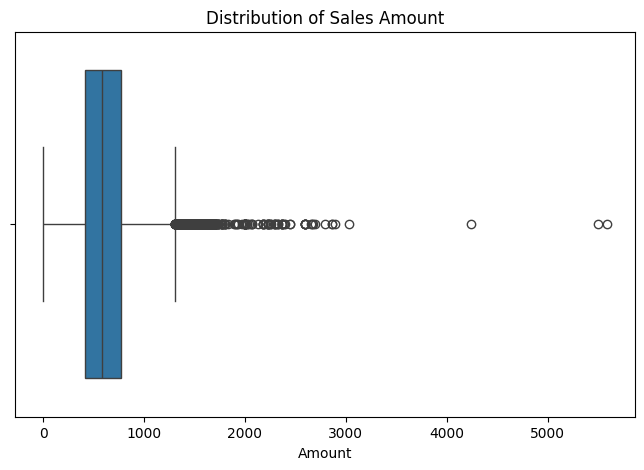

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Amount"])

plt.title("Distribution of Sales Amount")

plt.show()

### Insight

- The box plot highlights the distribution of sales amounts and any extreme values (outliers).
- Outlier analysis helps identify unusually high-value transactions that may require further business investigation.

## KPI Summary

The table below summarizes the key performance indicators calculated during the analysis.

In [66]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value"
    ],
    "Value": [
        f"₹{total_revenue:,.2f}",
        total_orders,
        total_quantity,
        f"₹{average_order_value:.2f}"
    ]
})

kpi

,Metric,Value
0,Total Revenue,"₹78,496,786.39"
1,Total Orders,120229
2,Total Quantity Sold,116496
3,Average Order Value,₹609.41


# Business Insights

1. Total revenue generated was **₹78.50 million**, indicating strong overall sales performance.

2. Sales were recorded between **March 2022 and June 2022**, helping identify monthly sales trends.

3. A few product categories contributed significantly to overall revenue, making them key products for the business.

4. The top-performing states generated a major share of sales, indicating high-demand regions.

5. Medium and larger product sizes received the highest number of orders, showing customer preferences.

6. Most orders were successfully fulfilled and shipped, reflecting an efficient fulfillment process.

7. The highest-order cities present good opportunities for targeted marketing and faster delivery services.

# Recommendations

- Increase inventory for top-selling product categories and popular sizes.
- Focus marketing campaigns on high-performing cities and states.
- Improve delivery performance in regions with delayed or cancelled orders.
- Regularly monitor sales trends to prepare for seasonal demand.
- Use data-driven inventory planning to reduce stock shortages and overstocking.

# Conclusion

This project analyzed Amazon sales data to identify sales trends, customer purchasing behavior, product performance, fulfillment methods, and geographical sales distribution. The analysis provided valuable business insights and recommendations that can help improve inventory management, customer satisfaction, and overall business performance through data-driven decision-making.